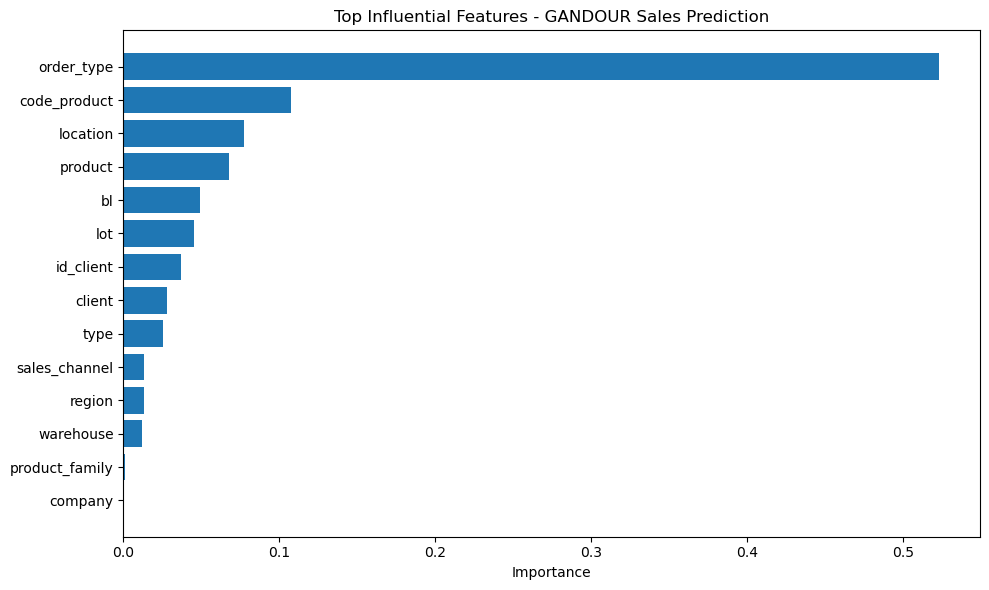

In [1]:
# Alternative to SHAP using feature_importances_

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("../data/cleaned_gandour_sales.csv")

# Cible
target_col = "quantity"
features_to_drop = [target_col, "date"]

X = df.drop(columns=features_to_drop)
y = df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Sort and plot
importances_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importances_df = importances_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importances_df["Feature"], importances_df["Importance"])
plt.xlabel("Importance")
plt.title("Top Influential Features - GANDOUR Sales Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
